# BioAI Hub — Layer 5: Transfer Learning con EfficientNet-B3

En layers anteriores entrené BioAICNN desde cero sobre Chest X-Ray Kaggle (2 clases, ~6k imágenes). Acá hago fine-tuning de EfficientNet-B3 pre-entrenado en ImageNet sobre NIH ChestX-ray14 (14 patologías, 112k imágenes).

La diferencia fundamental: en vez de inicializar con pesos aleatorios, parto de un modelo que ya aprendió a detectar bordes, texturas y formas en millones de imágenes. Solo tengo que enseñarle a aplicar ese conocimiento a radiografías.

**Mejoras respecto al borrador anterior:**
- Extracción del zip al disco local (I/O 10× más rápido que Drive directo)
- Splits con fallback: si el runtime se reinició y el pkl no existe, se regenera automáticamente
- Mixed precision (AMP) para ~40% menos tiempo de entrenamiento en T4
- `batch_size=64` — T4 16GB lo tolera sin problemas

## 0. Setup

Montar Drive y definir rutas. Cambiar a **T4 GPU** antes de ejecutar (Runtime → Cambiar tipo de entorno de ejecución).

In [2]:
import os, pickle
import torch
import torch.nn as nn
import numpy as np
import platform

# Detección automática de entorno
if os.path.exists('C:/nih_dataset'):
    # PC local Windows
    WORK_DIR = 'C:/nih_training'
    NIH_DIR  = 'C:/nih_dataset'
else:
    # Google Colab
    from google.colab import drive
    drive.mount('/content/drive')
    WORK_DIR = os.path.expanduser('~/bioai-colab-data')
    NIH_DIR  = os.path.join(WORK_DIR, 'nih-data')

IMG_LOCAL = os.path.join(WORK_DIR, 'nih_images')
os.makedirs(IMG_LOCAL, exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)

NUM_WORKERS = 0 if platform.system() == 'Windows' else 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Entorno: {"local Windows" if os.path.exists("C:/nih_dataset") else "Colab"}')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True

Entorno: local Windows
Device: cuda
GPU: NVIDIA GeForce RTX 3070
VRAM: 8.6 GB


## 1. Extraer imágenes del zip al disco local

Leer imágenes directamente desde Drive es lento (57k+ archivos = mucho overhead de FUSE). La solución: extraer el zip una vez por sesión al disco local del VM (`/content/nih_images/`), que actúa como SSD.

Las imágenes se **redimensionan a 224×224 durante la extracción** — es la resolución que usa el modelo de todas formas. Esto reduce el espacio de ~42GB a ~5GB y cabe sin problemas en el disco local de Colab. La celda verifica cuántas imágenes hay localmente antes de extraer — si ya están todas, se salta automáticamente.

In [3]:
from pathlib import Path
from PIL import Image as PILImage

IMG_SIZE = 224

n_local = len([f for f in os.listdir(IMG_LOCAL) if f.lower().endswith('.jpg')])
print(f'Imágenes locales ya procesadas: {n_local:,}')

if n_local < 112_000:
    # En Colab: extraer desde zip. En local: leer desde las 12 carpetas ya extraídas.
    if os.path.exists('C:/nih_dataset'):
        img_sources = sorted(Path(NIH_DIR).glob('images_*/images/*.png'))
    else:
        import io, zipfile
        ZIP_PATH = os.path.join(NIH_DIR, 'data.zip')
        if not os.path.exists(ZIP_PATH):
            raise FileNotFoundError(f'No se encontró {ZIP_PATH}')
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            img_sources = [m for m in zf.infolist() if m.filename.lower().endswith('.png')]

    total = len(img_sources) if hasattr(img_sources, '__len__') else '?'
    print(f'Imágenes fuente encontradas: {total:,}')
    print(f'Redimensionando a {IMG_SIZE}×{IMG_SIZE} y guardando como JPEG...')

    if os.path.exists('C:/nih_dataset'):
        for i, src_path in enumerate(img_sources):
            fname  = src_path.stem + '.jpg'
            target = os.path.join(IMG_LOCAL, fname)
            if not os.path.exists(target):
                img = PILImage.open(src_path).convert('RGB')
                img = img.resize((IMG_SIZE, IMG_SIZE), PILImage.LANCZOS)
                img.save(target, format='JPEG', quality=95)
            if (i + 1) % 10_000 == 0:
                print(f'  {i+1:,} / {total:,}')
    else:
        import io, zipfile
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            for i, member in enumerate(img_sources):
                fname  = os.path.splitext(os.path.basename(member.filename))[0] + '.jpg'
                target = os.path.join(IMG_LOCAL, fname)
                if not os.path.exists(target):
                    with zf.open(member) as src:
                        img = PILImage.open(io.BytesIO(src.read())).convert('RGB')
                        img = img.resize((IMG_SIZE, IMG_SIZE), PILImage.LANCZOS)
                        img.save(target, format='JPEG', quality=95)
                if (i + 1) % 10_000 == 0:
                    print(f'  {i+1:,} / {total:,}')

    n_final = len([f for f in os.listdir(IMG_LOCAL) if f.lower().endswith('.jpg')])
    print(f'Procesamiento completo. Imágenes locales: {n_final:,}')
else:
    print('Preprocesamiento ya completo, saltando.')

Imágenes locales ya procesadas: 112,120
Preprocesamiento ya completo, saltando.


## 2. Cargar splits

Los splits se generaron en Layer 4 y se guardaron en Drive como `nih_splits.pkl`. Si el runtime se reinició y el archivo no existe en Drive, esta celda los regenera con los mismos parámetros (`random_state=42`, splits oficiales del paper).

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

PKL_PATH = os.path.join(WORK_DIR, 'nih_splits.pkl')

if os.path.exists(PKL_PATH):
    print('Cargando splits desde Drive...')
    with open(PKL_PATH, 'rb') as f:
        estado = pickle.load(f)
    df_train    = estado['df_train']
    df_val      = estado['df_val']
    df_test     = estado['df_test']
    pos_weights = estado['pos_weights']
    PATOLOGIAS  = estado['patologias']

else:
    print('nih_splits.pkl no encontrado — regenerando (random_state=42)...')

    PATOLOGIAS = [
        'Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax',
        'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia',
        'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
    ]

    csv_path = os.path.join(NIH_DIR, 'Data_Entry_2017.csv')
    df       = pd.read_csv(csv_path)

    def leer_lista(path):
        with open(path) as f:
            return set(line.strip() for line in f if line.strip())

    train_val_list = leer_lista(os.path.join(NIH_DIR, 'train_val_list.txt'))
    test_list      = leer_lista(os.path.join(NIH_DIR, 'test_list.txt'))

    df_train_val = df[df['Image Index'].isin(train_val_list)].copy()
    df_test      = df[df['Image Index'].isin(test_list)].copy()
    df_train, df_val = train_test_split(df_train_val, test_size=0.1, random_state=42)

    total = len(df_train)
    pos_weights = []
    for pat in PATOLOGIAS:
        n_pos = df_train['Finding Labels'].str.contains(pat).sum()
        n_neg = total - n_pos
        pos_weights.append(n_neg / (n_pos + 1e-6))

    with open(PKL_PATH, 'wb') as f:
        pickle.dump({
            'df_train': df_train, 'df_val': df_val, 'df_test': df_test,
            'pos_weights': pos_weights, 'patologias': PATOLOGIAS,
        }, f)
    print('Splits guardados en Drive para la próxima sesión')

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Patologías: {PATOLOGIAS}')

Cargando splits desde Drive...
Train: 77,871 | Val: 8,653 | Test: 25,596
Patologías: ['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia']


## 3. Dataset y DataLoaders

Las imágenes en `/content/nih_images/` ya están en 224×224 (se redimensionaron durante la extracción), así que los transforms no necesitan `Resize`. `batch_size=64` para aprovechar la VRAM de T4.

In [5]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class NIHChestDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname    = os.path.splitext(row['Image Index'])[0] + '.jpg'
        img_path = os.path.join(self.img_dir, fname)
        image    = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        labels_str = row['Finding Labels']
        label_vec  = torch.zeros(len(PATOLOGIAS), dtype=torch.float32)
        if labels_str != 'No Finding':
            for pat in labels_str.split('|'):
                if pat in PATOLOGIAS:
                    label_vec[PATOLOGIAS.index(pat)] = 1.0

        return image, label_vec


# Sin Resize — las imágenes ya están en 224×224 desde el preprocesamiento
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = NIHChestDataset(df_train, IMG_LOCAL, transform=transform_train)
val_ds   = NIHChestDataset(df_val,   IMG_LOCAL, transform=transform_eval)
test_ds  = NIHChestDataset(df_test,  IMG_LOCAL, transform=transform_eval)

# RTX 3070 (8GB) → batch_size=32. Subir a 64 si la VRAM lo permite.
BATCH = 32

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train loader: {len(train_loader)} batches  (batch_size={BATCH})')
print(f'Val loader:   {len(val_loader)} batches')
print(f'Test loader:  {len(test_loader)} batches')

Train loader: 2434 batches  (batch_size=32)
Val loader:   271 batches
Test loader:  800 batches


## 4. Modelo — EfficientNet-B3

EfficientNet escala ancho, profundidad y resolución de forma balanceada. La variante B3 tiene ~12M de parámetros — lo suficientemente grande para capturar patrones complejos en radiografías sin ser prohibitivo en tiempo de entrenamiento.

Reemplazo la última capa del clasificador por una de 14 salidas, una por patología. No uso softmax — `BCEWithLogitsLoss` aplica sigmoid internamente por patología, lo que permite que múltiples clases sean positivas al mismo tiempo.

In [6]:
import torchvision.models as models


def construir_efficientnet(num_classes=14, freeze_backbone=True):
    model = models.efficientnet_b3(weights='IMAGENET1K_V1')

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model.to(device)


model = construir_efficientnet(freeze_backbone=True)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Parámetros totales:      {total_params:,}')
print(f'Parámetros entrenables:  {trainable_params:,}  (solo el clasificador)')

Parámetros totales:      10,717,750
Parámetros entrenables:  21,518  (solo el clasificador)


## 5. Fine-tuning en dos fases

**Fase 1** — backbone congelado, solo entreno el clasificador. Si lo descongelara desde el principio con lr alto, los pesos pre-entrenados se destruirían antes de que el clasificador se estabilice.

**Fase 2** — desglaceo todo y entreno con lr mucho más bajo. El backbone se ajusta sutilmente para features específicas de radiografías sin perder el conocimiento de ImageNet.

**Mixed precision (AMP)**: `autocast` permite que las operaciones de forward usen fp16 donde es seguro, reduciendo el tiempo de entrenamiento ~40% en T4 sin pérdida de precisión.

In [7]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float32).to(device)
criterion          = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)
scaler             = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_labels, all_probs = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)

            if training:
                optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * images.size(0)
            all_labels.append(labels.cpu().numpy())
            all_probs.append(torch.sigmoid(outputs).detach().cpu().float().numpy())

    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)

    aucs = []
    for i in range(len(PATOLOGIAS)):
        if all_labels[:, i].sum() >= 2:
            aucs.append(roc_auc_score(all_labels[:, i], all_probs[:, i]))

    mean_auc = np.mean(aucs) if aucs else 0.0
    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, mean_auc, all_labels, all_probs


def guardar_checkpoint(model, optimizer, epoch, val_loss, val_auc, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'val_auc': val_auc,
    }, path)


print('Utilidades definidas (AMP habilitado)')

Utilidades definidas (AMP habilitado)


C:\Users\Tomas\AppData\Local\Temp\ipykernel_17688\798563670.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler             = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


### Fase 1: backbone congelado (3 epochs)

Solo se actualizan los pesos del clasificador. LR alto (1e-3) porque partimos de pesos aleatorios en esa capa.

In [8]:
CHECKPOINT_F1 = os.path.join(WORK_DIR, 'efficientnet_fase1_best.pth')

optimizer_f1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)

EPOCHS_F1   = 3
best_auc_f1 = 0.0

print('=== Fase 1: backbone congelado ===')
for epoch in range(1, EPOCHS_F1 + 1):
    train_loss, train_auc, _, _ = run_epoch(model, train_loader, optimizer=optimizer_f1)
    val_loss,   val_auc,   _, _ = run_epoch(model, val_loader)

    mejoro = val_auc > best_auc_f1
    if mejoro:
        best_auc_f1 = val_auc
        guardar_checkpoint(model, optimizer_f1, epoch, val_loss, val_auc, CHECKPOINT_F1)

    print(f'Epoch {epoch}/{EPOCHS_F1}  '
          f'train_loss={train_loss:.4f}  train_auc={train_auc:.3f}  '
          f'val_loss={val_loss:.4f}  val_auc={val_auc:.3f}'
          f'{"  ← guardado" if mejoro else ""}')

print(f'\nMejor AUC Fase 1: {best_auc_f1:.4f}')

=== Fase 1: backbone congelado ===


  0%|          | 0/2434 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
  0%|          | 0/271 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                                                 

Epoch 1/3  train_loss=1.2346  train_auc=0.669  val_loss=1.2389  val_auc=0.700  ← guardado


  0%|          | 0/2434 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
  0%|          | 0/271 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                                                 

Epoch 2/3  train_loss=1.2067  train_auc=0.695  val_loss=1.2391  val_auc=0.708  ← guardado


  0%|          | 0/2434 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
  0%|          | 0/271 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                                                 

Epoch 3/3  train_loss=1.2069  train_auc=0.696  val_loss=1.2256  val_auc=0.711  ← guardado

Mejor AUC Fase 1: 0.7107


### Fase 2: backbone descongelado (5 epochs)

Se carga el mejor checkpoint de Fase 1, se descongela todo el backbone y se entrena con LR bajo (1e-4). El scheduler reduce el LR a la mitad si el val_auc no mejora en 2 epochs consecutivas.

In [9]:
CHECKPOINT_F2 = os.path.join(WORK_DIR, 'efficientnet_fase2_best.pth')

ckpt = torch.load(CHECKPOINT_F1, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Checkpoint Fase 1 cargado — epoch {ckpt["epoch"]}, val_auc={ckpt["val_auc"]:.4f}')

for param in model.parameters():
    param.requires_grad = True

trainable_f2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables Fase 2: {trainable_f2:,}')

optimizer_f2 = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler    = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_f2, mode='max', factor=0.5, patience=2
)

EPOCHS_F2   = 5
best_auc_f2 = 0.0

print('\n=== Fase 2: backbone descongelado ===')
for epoch in range(1, EPOCHS_F2 + 1):
    train_loss, train_auc, _, _ = run_epoch(model, train_loader, optimizer=optimizer_f2)
    val_loss,   val_auc,   _, _ = run_epoch(model, val_loader)

    scheduler.step(val_auc)
    lr_actual = optimizer_f2.param_groups[0]['lr']

    mejoro = val_auc > best_auc_f2
    if mejoro:
        best_auc_f2 = val_auc
        guardar_checkpoint(model, optimizer_f2, epoch, val_loss, val_auc, CHECKPOINT_F2)

    print(f'Epoch {epoch}/{EPOCHS_F2}  '
          f'train_loss={train_loss:.4f}  train_auc={train_auc:.3f}  '
          f'val_loss={val_loss:.4f}  val_auc={val_auc:.3f}  '
          f'lr={lr_actual:.2e}'
          f'{"  ← guardado" if mejoro else ""}')

print(f'\nMejor AUC Fase 2: {best_auc_f2:.4f}')

Checkpoint Fase 1 cargado — epoch 3, val_auc=0.7107
Parámetros entrenables Fase 2: 10,717,750

=== Fase 2: backbone descongelado ===


  0%|          | 0/2434 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
  0%|          | 0/271 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                                                 

Epoch 1/5  train_loss=1.1328  train_auc=0.743  val_loss=1.1131  val_auc=0.772  lr=1.00e-04  ← guardado


  0%|          | 0/2434 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
  0%|          | 0/271 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                                                 

Epoch 2/5  train_loss=1.0438  train_auc=0.785  val_loss=1.0714  val_auc=0.791  lr=1.00e-04  ← guardado


...

Epoch 3/5  train_loss=0.9861  train_auc=0.808  val_loss=1.0194  val_auc=0.814  lr=1.00e-04  ← guardado


  0%|          | 0/2434 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
  0%|          | 0/271 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                                                 

Epoch 4/5  train_loss=0.9554  train_auc=0.820  val_loss=1.0199  val_auc=0.819  lr=1.00e-04  ← guardado


  0%|          | 0/2434 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
  0%|          | 0/271 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                                                 

Epoch 5/5  train_loss=0.9047  train_auc=0.837  val_loss=1.0104  val_auc=0.820  lr=1.00e-04  ← guardado

Mejor AUC Fase 2: 0.8204


## 6. Evaluación en test set

Se carga el mejor checkpoint de Fase 2 y se evalúa sobre el test set oficial del paper. Los papers de referencia (CheXNet, DenseNet121) reportan AUC promedio entre 0.74 y 0.84 por patología.

In [10]:
ckpt_f2 = torch.load(CHECKPOINT_F2, map_location=device, weights_only=False)
model.load_state_dict(ckpt_f2['model_state_dict'])
print(f'Checkpoint cargado — epoch {ckpt_f2["epoch"]}, val_auc={ckpt_f2["val_auc"]:.4f}')

_, _, test_labels, test_probs = run_epoch(model, test_loader)

print('\n--- AUC-ROC por patología (test set) ---')
aucs_por_pat = {}
for i, pat in enumerate(PATOLOGIAS):
    n_pos = int(test_labels[:, i].sum())
    if n_pos >= 2:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        aucs_por_pat[pat] = auc
        print(f'  {pat:25s}  AUC={auc:.3f}  ({n_pos} casos positivos)')
    else:
        print(f'  {pat:25s}  — (insuficientes casos positivos)')

mean_auc = np.mean(list(aucs_por_pat.values()))
print(f'\nAUC-ROC promedio: {mean_auc:.4f}')

Checkpoint cargado — epoch 5, val_auc=0.8204


  0%|          | 0/800 [00:00<?, ?it/s]C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\798563670.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                                                 


--- AUC-ROC por patología (test set) ---
  Atelectasis                AUC=0.738  (3279 casos positivos)
  Consolidation              AUC=0.719  (1815 casos positivos)
  Infiltration               AUC=0.695  (6112 casos positivos)
  Pneumothorax               AUC=0.851  (2665 casos positivos)
  Edema                      AUC=0.831  (925 casos positivos)
  Emphysema                  AUC=0.884  (1093 casos positivos)
  Fibrosis                   AUC=0.804  (435 casos positivos)
  Effusion                   AUC=0.800  (4658 casos positivos)
  Pneumonia                  AUC=0.689  (555 casos positivos)
  Pleural_Thickening         AUC=0.750  (1143 casos positivos)
  Cardiomegaly               AUC=0.856  (1069 casos positivos)
  Nodule                     AUC=0.709  (1623 casos positivos)
  Mass                       AUC=0.766  (1748 casos positivos)
  Hernia                     AUC=0.897  (86 casos positivos)

AUC-ROC promedio: 0.7850


C:\Users\Tomas\AppData\Local\Temp\ipykernel_5056\1755736977.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pats, rotation=40, ha='right')


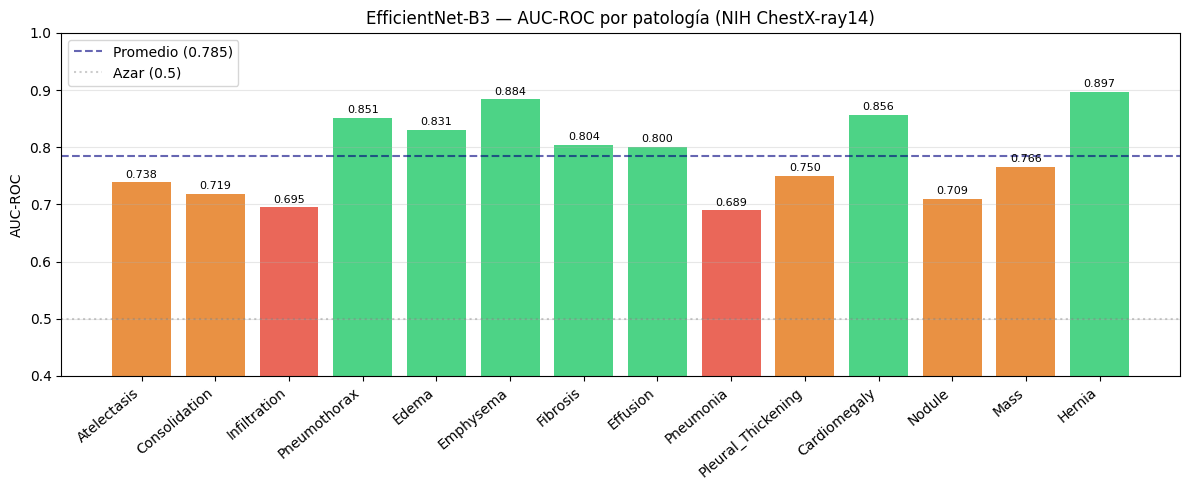

In [11]:
import matplotlib.pyplot as plt

pats    = list(aucs_por_pat.keys())
aucs    = list(aucs_por_pat.values())
colores = ['#2ecc71' if a >= 0.80 else '#e67e22' if a >= 0.70 else '#e74c3c' for a in aucs]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(pats, aucs, color=colores, alpha=0.85)
ax.axhline(y=mean_auc, color='navy', linestyle='--', alpha=0.6, label=f'Promedio ({mean_auc:.3f})')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.4, label='Azar (0.5)')
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('AUC-ROC')
ax.set_title('EfficientNet-B3 — AUC-ROC por patología (NIH ChestX-ray14)')
ax.set_xticklabels(pats, rotation=40, ha='right')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'efficientnet_auc_por_patologia.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. Comparativa BioAICNN vs EfficientNet-B3

No es una comparación directa — son datasets y tareas distintas. BioAICNN resuelve clasificación binaria sobre ~6k imágenes. EfficientNet resuelve multi-label sobre 112k. Sirve para mostrar la progresión del proyecto y entender el trade-off entre complejidad del problema y capacidad del modelo.

In [12]:
print('=' * 60)
print(f'{"":30s} {"BioAICNN":>12} {"EfficientNet-B3":>15}')
print('=' * 60)
print(f'{"Dataset":30s} {"Kaggle":>12} {"NIH":>15}')
print(f'{"Imágenes":30s} {"5,800":>12} {"112,120":>15}')
print(f'{"Clases":30s} {"2":>12} {"14":>15}')
print(f'{"Tipo de clasificación":30s} {"binaria":>12} {"multi-label":>15}')
print(f'{"Parámetros":30s} {"~500k":>12} {"~12M":>15}')
print(f'{"AUC-ROC":30s} {"0.942":>12} {mean_auc:>15.3f}')
print(f'{"Pesos iniciales":30s} {"aleatorios":>12} {"ImageNet":>15}')
print('=' * 60)
print()
print('Nota: AUC-ROC más bajo en NIH es esperado — 14 patologías con')
print('clases muy desbalanceadas es un problema mucho más difícil.')
print('Los papers de referencia reportan 0.74–0.84 por patología.')

                                   BioAICNN EfficientNet-B3
Dataset                              Kaggle             NIH
Imágenes                              5,800         112,120
Clases                                    2              14
Tipo de clasificación               binaria     multi-label
Parámetros                            ~500k            ~12M
AUC-ROC                               0.942           0.785
Pesos iniciales                  aleatorios        ImageNet

Nota: AUC-ROC más bajo en NIH es esperado — 14 patologías con
clases muy desbalanceadas es un problema mucho más difícil.
Los papers de referencia reportan 0.74–0.84 por patología.


## 8. Exportar modelo

Se guardan dos formatos:
- **`.pth`** — pesos de PyTorch, para continuar training o usar con torchvision
- **`.onnx`** — portable, corre en cualquier framework (TensorRT, OpenCV, ONNX Runtime)

In [14]:
torch.save(
    model.state_dict(),
    os.path.join(WORK_DIR, 'efficientnet_b3_nih_final.pth')
)

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model,
    dummy_input,
    os.path.join(WORK_DIR, 'efficientnet_b3_nih.onnx'),
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image': {0: 'batch_size'}, 'logits': {0: 'batch_size'}},
    opset_version=17,
)

print('Archivos exportados:')
for archivo in sorted(os.listdir(WORK_DIR)):
    path = os.path.join(WORK_DIR, archivo)
    if os.path.isfile(path):
        print(f'  {archivo:50s} {os.path.getsize(path)/1e6:.1f} MB')
    else:
        print(f'  {archivo}/')

Archivos exportados:
  efficientnet_auc_por_patologia.png                 0.1 MB
  efficientnet_b3_nih.onnx                           42.8 MB
  efficientnet_b3_nih_final.pth                      43.4 MB
  efficientnet_fase1_best.pth                        43.6 MB
  efficientnet_fase2_best.pth                        129.5 MB
  nih_images/
  nih_splits.pkl                                     11.9 MB


## 9. Grad-CAM — qué zona de la radiografía activó cada patología

GradCAM hookea `features[-1]` (la última capa convolucional de EfficientNet-B3, salida 7×7×1536). Para una patología dada:
1. Forward pass → guarda los feature maps de esa capa
2. Backward sobre el score de la clase → guarda los gradientes
3. Promedia los gradientes por canal → pesos de importancia
4. Suma ponderada de feature maps → mapa 7×7 → ReLU → resize a 224×224 → overlay JET

El resultado muestra qué región de la radiografía el modelo encontró más relevante para predecir cada patología.

In [8]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm_lib

# Ruta al modelo — busca primero en Modelos/, fallback a WORK_DIR
_model_candidates = [
    'C:/Users/ttorillo/Documents/Modelos/efficientnet_fase2_best.pth',
    'C:/nih_training/efficientnet_fase2_best.pth',
    os.path.join(WORK_DIR, 'efficientnet_fase2_best.pth'),
]
MODEL_PATH = next((p for p in _model_candidates if os.path.exists(p)), None)
if MODEL_PATH is None:
    raise FileNotFoundError('No se encontró efficientnet_fase2_best.pth')

cam_model = construir_efficientnet(num_classes=14, freeze_backbone=False)
ckpt_cam  = torch.load(MODEL_PATH, map_location=device, weights_only=False)
cam_model.load_state_dict(ckpt_cam['model_state_dict'])
cam_model.eval()
print(f'Modelo cargado desde: {MODEL_PATH}')
print(f'val_auc del checkpoint: {ckpt_cam["val_auc"]:.4f}')


class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._hooks = [
            target_layer.register_forward_hook(self._fwd),
            target_layer.register_full_backward_hook(self._bwd),
        ]

    def _fwd(self, module, inp, out):
        self.activations = out.detach()

    def _bwd(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, img_tensor, class_idx):
        self.model.zero_grad()
        out = self.model(img_tensor)
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = cam - cam.min()
        cam     = cam / (cam.max() + 1e-8)
        return cam.squeeze().cpu().numpy()

    def remove(self):
        for h in self._hooks:
            h.remove()


gradcam = GradCAM(cam_model, cam_model.features[-1])
print('GradCAM listo — hookeando features[-1] (7×7 feature maps)')

Modelo cargado desde: C:/nih_training/efficientnet_fase2_best.pth
val_auc del checkpoint: 0.8204
GradCAM listo — hookeando features[-1] (7×7 feature maps)


Labels reales: Effusion|Infiltration


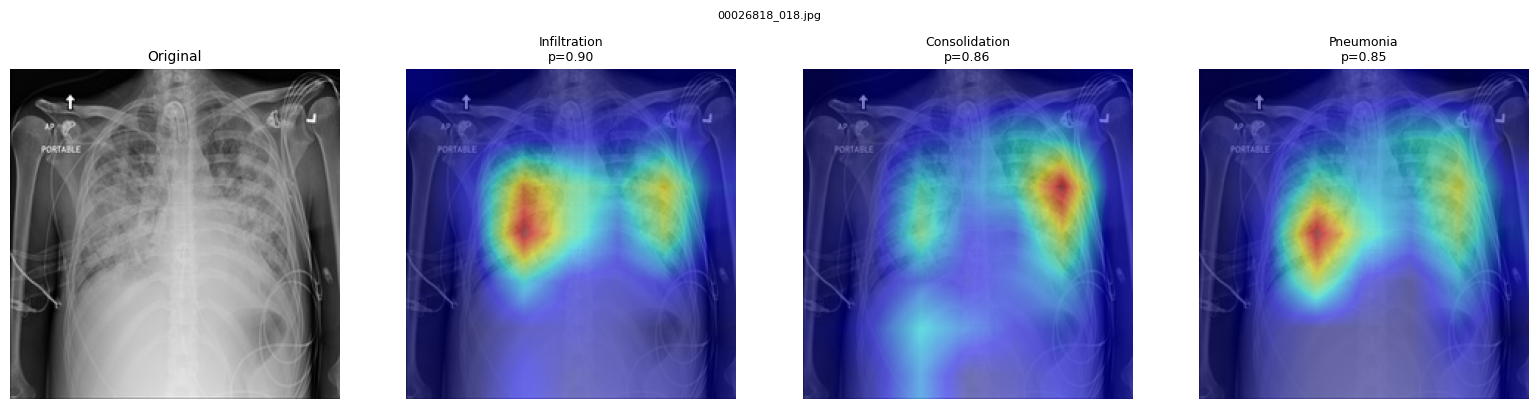

Labels reales: Infiltration


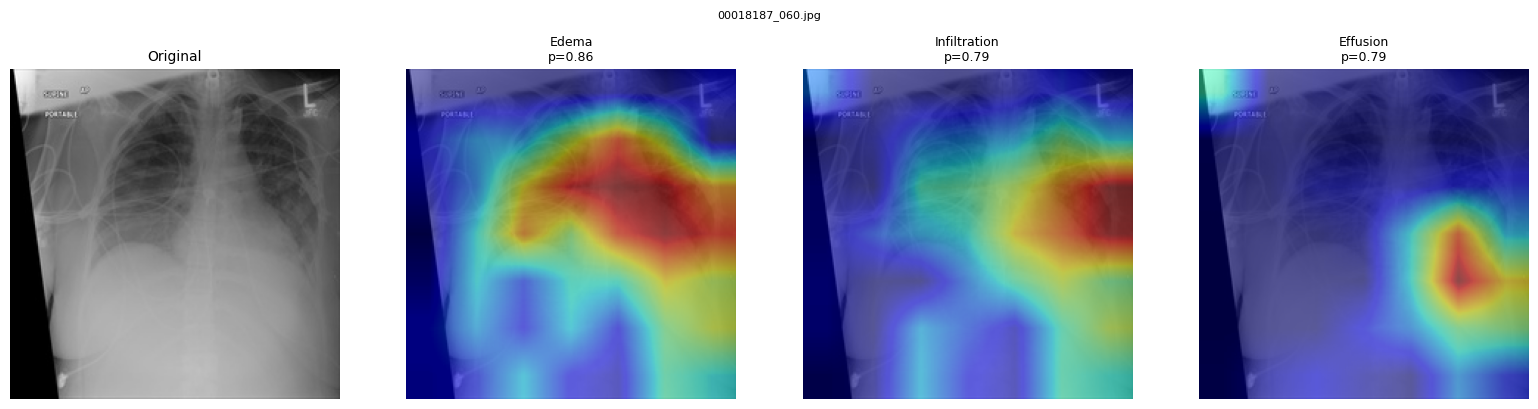

Labels reales: Infiltration|Nodule|Pneumothorax


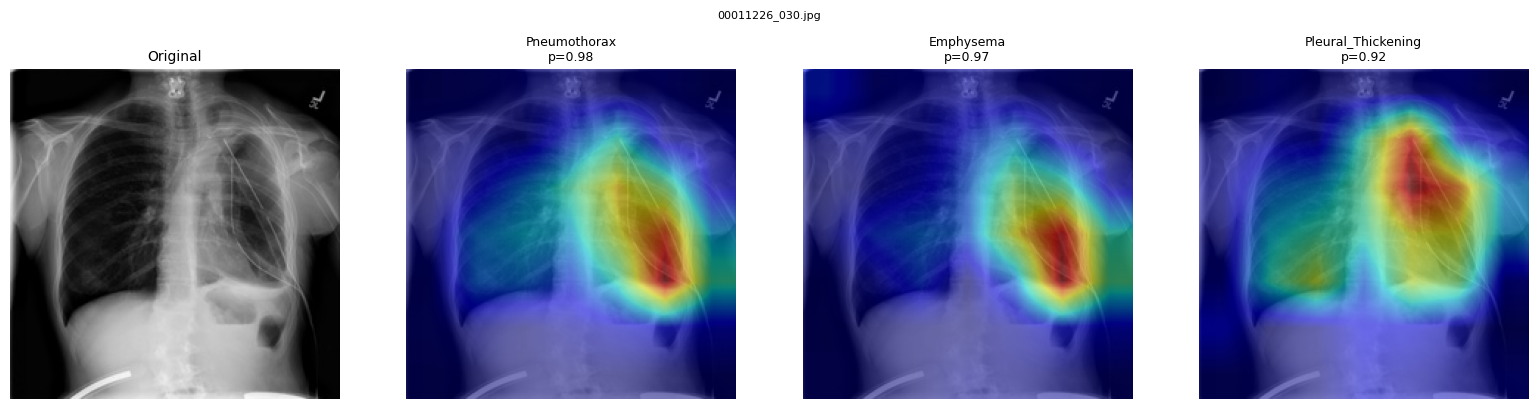

Labels reales: Edema


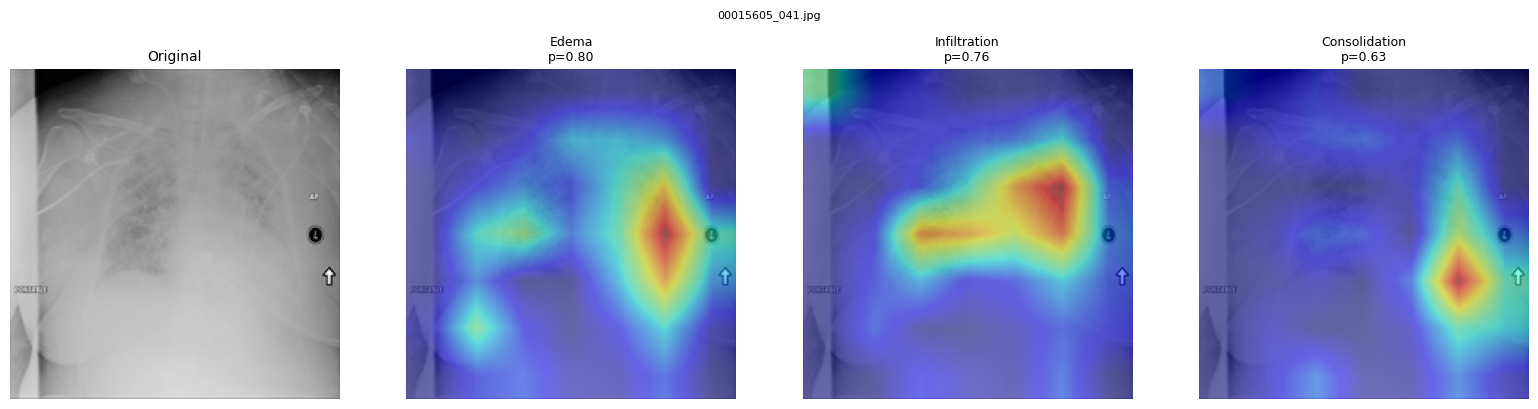

Labels reales: Atelectasis|Pneumothorax


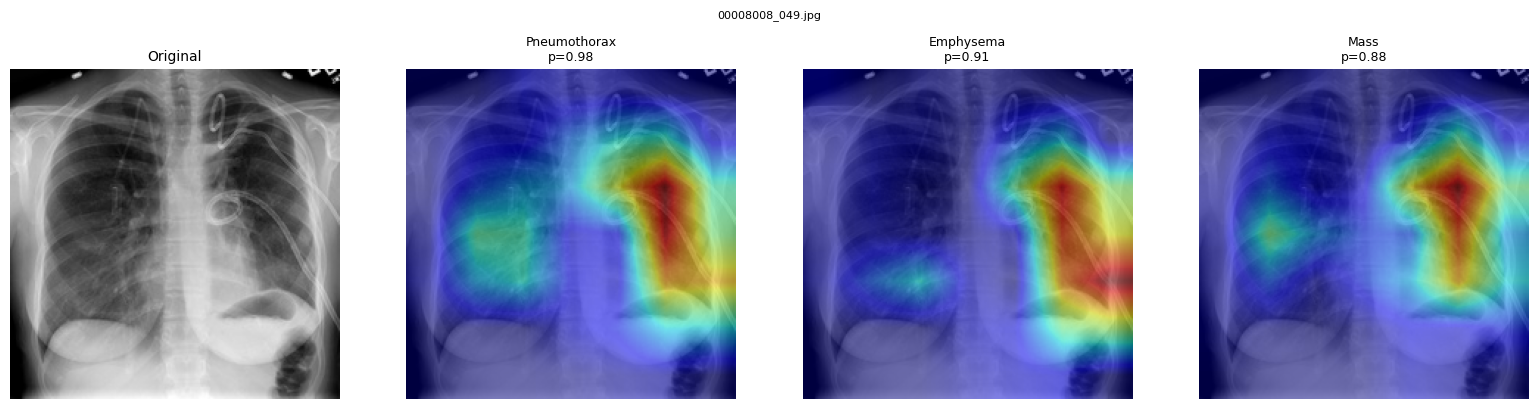

In [9]:
def overlay_gradcam(img_pil, cam_np):
    cam_resized = np.array(
        Image.fromarray((cam_np * 255).astype(np.uint8)).resize(img_pil.size, Image.BILINEAR)
    ) / 255.0
    heatmap = cm_lib.jet(cam_resized)[:, :, :3]
    overlay = 0.5 * np.array(img_pil) / 255.0 + 0.5 * heatmap
    return np.clip(overlay, 0, 1)


def mostrar_gradcam(img_path, top_k=3):
    img_pil    = Image.open(img_path).convert('RGB')
    img_tensor = transform_eval(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.sigmoid(cam_model(img_tensor))[0].cpu().numpy()

    top_idx = probs.argsort()[::-1][:top_k]

    fig, axes = plt.subplots(1, top_k + 1, figsize=(4 * (top_k + 1), 4))

    axes[0].imshow(img_pil, cmap='gray')
    axes[0].set_title('Original', fontsize=10)
    axes[0].axis('off')

    for i, idx in enumerate(top_idx):
        cam_np  = gradcam.generate(img_tensor, int(idx))
        overlay = overlay_gradcam(img_pil, cam_np)
        axes[i + 1].imshow(overlay)
        axes[i + 1].set_title(f'{PATOLOGIAS[idx]}\np={probs[idx]:.2f}', fontsize=9)
        axes[i + 1].axis('off')

    plt.suptitle(os.path.basename(img_path), fontsize=8, y=1.01)
    plt.tight_layout()
    plt.savefig(
        os.path.join(WORK_DIR, f'gradcam_{os.path.splitext(os.path.basename(img_path))[0]}.png'),
        dpi=100, bbox_inches='tight'
    )
    plt.show()


# 5 imágenes del test set con al menos una patología
muestras = df_test[df_test['Finding Labels'] != 'No Finding'].sample(5, random_state=7)

for _, row in muestras.iterrows():
    fname    = os.path.splitext(row['Image Index'])[0] + '.jpg'
    img_path = os.path.join(IMG_LOCAL, fname)
    if os.path.exists(img_path):
        print(f"Labels reales: {row['Finding Labels']}")
        mostrar_gradcam(img_path, top_k=3)